# Figure 2C and Figure 2D — shared-universe candidate evidence, MoA composition, and pathway-centroid agreement

Got the fig 5c and 5d.

Purpose:
1. Replot the drug-level top-20 map using the **shared observed-predicted drug universe** and `clinical_phase` from Drug Repurposing Hub metadata.
2. Plot Figure 2D-left: top-20 broad MoA composition for observed LINCS and DEPICT-predicted LINCS.
3. Plot Figure 2D-right: class-level pathway-reversal agreement, restricted in the main figure to the two adequately represented classes: **PI3K-AKT-mTOR** and **RTK/TKI**.

**Implementation notes**
- Figures are displayed inline in the notebook cell and also saved as PDF/PNG/SVG.
- Rankings are built from the shared observed-predicted LINCS drug universe.
- Broad MoA classes are assigned from Drug Repurposing Hub `moa` and/or `target`.
- Candidate map clinical labels are assigned from Drug Repurposing Hub `clinical_phase`; these are general development-stage labels, **not NSCLC-specific evidence**.
- Pathway scoring uses the same deterministic signed weighted preranked GSEA logic as Analysis 3: rank genes by signed DGE from largest positive to largest negative, use `abs(DGE)^p` hit weights with `p=1`, use stable mergesort for ties, and report the signed extreme running-sum deviation.


## Required files

Put these files in `./data/` relative to this notebook:

```text
reverseScore_predicted_All.csv
reverseScore_observed_All.csv
repurposing_drugs_20200324.txt
diff_geneExp_meanPlate.csv
diff_geneExp_pred.csv
depict_analysis3_mechanism_panel.v1.Hs.symbols.gmt
E-GEOD-18842-A-AFFY-44-analytics.tsv
```

The NSCLC signature file is the tumor-vs-normal Expression Atlas file you previously read with `sep='\t'`. The notebook assumes positive `log2FC` means higher in NSCLC tumor than normal.

Outputs are saved to:

```text
figures/figure2/
tables/figure2/
```


In [1]:

# %%
%matplotlib inline
from pathlib import Path
import re
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
from IPython.display import display

# -------------------------
# User-editable paths
# -------------------------
PROJECT_DIR = Path.cwd()
DATA_DIR = PROJECT_DIR / "data"
FIG_DIR = PROJECT_DIR / "figures" / "figure2"
TABLE_DIR = PROJECT_DIR / "tables" / "figure2"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

FINAL_DF_PRED_PATH = DATA_DIR / "reverseScore_predicted_All.csv"
FINAL_DF_ORIG_PATH = DATA_DIR / "reverseScore_observed_All.csv"
DRUG_META_PATH = DATA_DIR / "repurposing_drugs_20200324.txt"
DF_DIFFEXP_OBS_PATH = DATA_DIR / "diff_geneExp_meanPlate.csv"
DF_DIFFEXP_PRED_PATH = DATA_DIR / "diff_geneExp_pred.csv"
GMT_PATH = DATA_DIR / "depict_analysis3_mechanism_panel.v1.Hs.symbols.gmt"

# Your original Expression Atlas NSCLC tumor-vs-normal signature file.
NSCLC_SIGNATURE_PATH = DATA_DIR / "E-GEOD-18842-A-AFFY-44-analytics.tsv"

# Keep False for tumor-vs-normal log2FC. Set True only if the file is already normal-vs-tumor/reversed.
NSCLC_SIGNATURE_IS_ALREADY_REVERSED = False

TOP_N = 20
MIN_DRUGS_PER_CLASS_FOR_CORRELATION = 1

# Match Analysis 3 deterministic signed weighted preranked GSEA.
MIN_LANDMARK_OVERLAP = 10
GSEA_WEIGHT_EXPONENT = 1.0
GSEA_TIE_RULE = "stable_mergesort_descending_signed_dge"


In [2]:

# %%
def set_publication_style():
    plt.rcParams.update({
        "figure.dpi": 150,
        "savefig.dpi": 600,
        "font.family": "DejaVu Sans",
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 9,
        "axes.titleweight": "bold",
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "legend.fontsize": 7,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
        "svg.fonttype": "none",
    })
set_publication_style()

SOURCE_ORDER = ["Observed LINCS", "DEPICT-predicted LINCS"]
SOURCE_SHORT = {"Observed LINCS": "Observed", "DEPICT-predicted LINCS": "DEPICT"}
SOURCE_COLORS = {"Observed LINCS": "#2F5F9E", "DEPICT-predicted LINCS": "#C85A35"}

# Full broad MoA display order for Figure 2D-left composition.
MOA_CLASSES_FOR_2D_LEFT = [
    "PI3K-AKT-mTOR",
    "RTK/TKI",
    "p53/apoptosis",
    "CDK/cell cycle",
    "MAPK/MEK/ERK",
    "Non-related/not found",
]

# Main Figure 2D-right is restricted to classes with enough top-20 representation
# in your current observed/predicted lists.
MOA_CLASSES_FOR_2D_RIGHT = [
    "PI3K-AKT-mTOR",
    "RTK/TKI",
]

PATHWAY_DISPLAY_ORDER = [
    "PI3K/AKT/mTOR",
    "mTORC1",
    "EGFR/ERBB",
    "MAPK cascades",
    "E2F targets",
    "G2M checkpoint",
    "DNA repair",
    "Apoptosis",
    "Chromatin modifiers",
    "Chromatin organization",
]

PATHWAY_RENAME = {
    "HALLMARK_PI3K_AKT_MTOR_SIGNALING": "PI3K/AKT/mTOR",
    "HALLMARK_MTORC1_SIGNALING": "mTORC1",
    "REACTOME_EGFR_ERBB_FAMILY_SIGNALING": "EGFR/ERBB",
    "REACTOME_MAPK_FAMILY_SIGNALING_CASCADES": "MAPK cascades",
    "HALLMARK_E2F_TARGETS": "E2F targets",
    "HALLMARK_G2M_CHECKPOINT": "G2M checkpoint",
    "HALLMARK_DNA_REPAIR": "DNA repair",
    "HALLMARK_APOPTOSIS": "Apoptosis",
    "REACTOME_CHROMATIN_MODIFYING_ENZYMES": "Chromatin modifiers",
    "REACTOME_CHROMATIN_ORGANIZATION": "Chromatin organization",
}


def normalize_drug_name(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.replace("–", "-").replace("—", "-").replace("−", "-")
    x = re.sub(r"[^a-z0-9]+", "", x)
    aliases = {
        "nvpbez235": "dactolisib",
        "bez235": "dactolisib",
        "gsk2126458": "omipalisib",
        "gdc0941": "pictilisib",
        "mepacrine": "quinacrine",
        "epoxycholesterol": "epoxycholesterol",
    }
    return aliases.get(x, x)


def read_csv_drop_unnamed(path, **kwargs):
    df = pd.read_csv(path, **kwargs)
    unnamed = [c for c in df.columns if str(c).startswith("Unnamed:")]
    if unnamed:
        df = df.drop(columns=unnamed)
    return df


def load_screening_tables():
    pred = read_csv_drop_unnamed(FINAL_DF_PRED_PATH)
    orig = read_csv_drop_unnamed(FINAL_DF_ORIG_PATH)
    required = {"pert_iname", "reverse_score"}
    for name, df in {"final_df_pred": pred, "final_df_orig": orig}.items():
        missing = required - set(df.columns)
        if missing:
            raise ValueError(f"{name} is missing required columns: {missing}")
    return pred, orig


def best_per_drug(df, source_label):
    tmp = df.dropna(subset=["pert_iname", "reverse_score"]).copy()
    idx = tmp.groupby("pert_iname")["reverse_score"].idxmax()
    out = tmp.loc[idx].copy()
    out = out.sort_values("reverse_score", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    out["source"] = source_label
    out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    return out


def load_drug_meta():
    try:
        meta = pd.read_csv(DRUG_META_PATH, sep="\t", skiprows=9)
    except Exception:
        meta = pd.read_csv(DRUG_META_PATH, sep="\t")
    meta = meta.rename(columns={c: c.strip() for c in meta.columns})
    name_candidates = ["pert_iname", "name", "drug", "compound", "broad_id"]
    name_col = next((c for c in name_candidates if c in meta.columns), None)
    if name_col is None:
        raise ValueError(f"Could not find drug-name column in drug_meta. Columns are: {list(meta.columns)}")
    meta["meta_drug_name"] = meta[name_col]
    meta["drug_key"] = meta["meta_drug_name"].map(normalize_drug_name)
    return meta.dropna(subset=["drug_key"]).drop_duplicates("drug_key", keep="first")


def assign_broad_moa_from_text(text):
    t = "" if pd.isna(text) else str(text).lower()
    t = t.replace("–", "-").replace("—", "-").replace("−", "-")
    if re.search(r"pi3k|phosphoinositide|akt\b|\bmtor\b|mtorc|pdk1", t):
        return "PI3K-AKT-mTOR"
    if re.search(r"\bmek\b|\berk\b|\bmapk\b|\braf\b|\bbraf\b|\bkras\b", t):
        return "MAPK/MEK/ERK"
    if re.search(r"egfr|erbb|her2|alk\b|ros1|\bmet\b|fgfr|vegfr|pdgfr|\bkit\b|flt3|igf-?1?r|ret\b|ntrk|tyrosine kinase|\btki\b", t):
        return "RTK/TKI"
    if re.search(r"\bcdk\b|cyclin|cell cycle|checkpoint|chk1|chk2|aurora|wee1|plk|polo", t):
        return "CDK/cell cycle"
    if re.search(r"p53|tp53|mdm2|apopto|bcl|death receptor|trail|dr4|dr5|retinoid", t):
        return "p53/apoptosis"
    return "Non-related/not found"


def annotate_meta_moa(meta):
    """Assign broad MoA classes from Drug Repurposing Hub MoA/target text only.

    We intentionally do not use clinical_phase for this annotation because
    clinical_phase is general drug-development status, not NSCLC-specific evidence.
    """
    text_cols = [c for c in ["moa", "target"] if c in meta.columns]
    if not text_cols:
        raise ValueError(
            "drug_meta must contain at least one of the columns ['moa', 'target'] "
            "to define broad_moa_class."
        )
    meta = meta.copy()
    meta["annotation_text"] = meta[text_cols].fillna("").astype(str).agg(" | ".join, axis=1)
    meta["broad_moa_class"] = meta["annotation_text"].map(assign_broad_moa_from_text)
    return meta


def find_clinical_phase_column(meta):
    candidates = ["clinical_phase", "Clinical Phase", "clinical phase", "phase", "Phase"]
    for c in candidates:
        if c in meta.columns:
            return c
    lower_map = {str(c).strip().lower(): c for c in meta.columns}
    for key in ["clinical_phase", "clinical phase", "phase"]:
        if key in lower_map:
            return lower_map[key]
    return None


def classify_clinical_phase(x):
    """Map Drug Repurposing Hub clinical_phase into compact plotting labels.

    These labels describe general development status, not NSCLC-specific evidence.
    """
    if pd.isna(x) or str(x).strip() == "":
        return "Unknown/not annotated"
    s = str(x).strip()
    sl = s.lower()

    # Numeric-like encodings occasionally appear in cleaned metadata.
    try:
        val = float(sl)
        if val >= 4:
            return "Launched/approved"
        if val >= 3:
            return "Phase 3"
        if val >= 2:
            return "Phase 2"
        if val >= 1:
            return "Phase 1"
        if val == 0:
            return "Preclinical"
    except Exception:
        pass

    if re.search(r"launch|approved|phase\s*4|phase\s*iv|market", sl):
        return "Launched/approved"
    if re.search(r"phase\s*3|phase\s*iii|phase iii|phase3", sl):
        return "Phase 3"
    if re.search(r"phase\s*2|phase\s*ii|phase ii|phase2|phase 1/2|phase i/ii|phase ii/i", sl):
        return "Phase 2"
    if re.search(r"phase\s*1|phase\s*i\b|phase i\b|phase1", sl):
        return "Phase 1"
    if re.search(r"preclinical|pre-clinical|probe|experimental", sl):
        return "Preclinical"
    return s


CLINICAL_PHASE_ORDER = [
    "Launched/approved",
    "Phase 3",
    "Phase 2",
    "Phase 1",
    "Preclinical",
    "Unknown/not annotated",
    "Not in top-20",
]

CLINICAL_PHASE_COLORS = {
    "Launched/approved": "#1A9850",       # deep green
    "Phase 3": "#66BD63",                # green
    "Phase 2": "#A6D96A",                # light green
    "Phase 1": "#FEE08B",                # yellow
    "Preclinical": "#F46D43",            # orange-red
    "Unknown/not annotated": "#BDBDBD",  # neutral gray
    "Not in top-20": "#F2F2F2",          # very light gray
}


def parse_gmt(path):
    gene_sets = {}
    with open(path, "r") as f:
        for line in f:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            name = parts[0]
            genes = [g.strip() for g in parts[2:] if g.strip()]
            gene_sets[name] = genes
    return gene_sets


def signed_preranked_es(scores, gene_set, weight_exponent=GSEA_WEIGHT_EXPONENT, min_overlap=MIN_LANDMARK_OVERLAP):
    """Deterministic signed weighted preranked GSEA ES.

    This matches the Analysis 3 global-scoring implementation:
    - rank all available genes from largest positive signed DGE to largest negative signed DGE;
    - use stable mergesort as the deterministic tie rule;
    - weight hits by abs(score)^p, with p=1 by default;
    - use equal decrement for misses;
    - return the signed extreme running-sum deviation.

    Positive ES means pathway genes are concentrated near the positively perturbed
    end of the ranked vector; negative ES means concentration near the negatively
    perturbed end.
    """
    s = pd.Series(scores).dropna().astype(float)
    if s.empty:
        return np.nan

    # Use upper-case symbols for robust matching across GMT, DGE, and Expression Atlas inputs.
    s.index = pd.Index([str(g).upper() for g in s.index], name=s.index.name)
    s = s[~s.index.duplicated(keep="first")]

    gene_set_upper = {str(g).upper() for g in gene_set}
    n_genes = s.shape[0]

    values = s.to_numpy(dtype=np.float32)
    genes = s.index.to_numpy(dtype=object)

    order = np.argsort(-values, kind="mergesort")
    ranked_values = values[order]
    ranked_genes = genes[order]

    hit = np.isin(ranked_genes, list(gene_set_upper)).astype(np.float32)
    n_hits = int(hit.sum())
    if n_hits < min_overlap or n_hits >= n_genes:
        return np.nan

    rank_abs = np.abs(ranked_values) ** float(weight_exponent)
    hit_weights = hit * rank_abs
    denom = float(hit_weights.sum())

    if denom <= 0 or not np.isfinite(denom):
        # Same mathematical fallback as Analysis 3 when all hit scores have zero magnitude:
        # use unweighted hits rather than returning an arbitrary zero.
        hit_weights = hit.copy()
        denom = float(hit_weights.sum())

    hit_step = hit_weights / denom
    miss_step = (1.0 - hit) / float(n_genes - n_hits)
    running = np.cumsum(hit_step - miss_step)

    max_es = float(np.max(running))
    min_es = float(np.min(running))
    return max_es if abs(max_es) >= abs(min_es) else min_es


def save_figure(fig, stem, show=True):
    """Display the figure inline in the notebook and save PDF/PNG/SVG copies.

    For VM/Jupyter execution, the figure is displayed explicitly in the output cell
    and also saved to disk. Do not close the figure here; closing before display can
    suppress inline output in some notebook frontends.
    """
    fig.tight_layout()
    if show:
        display(fig)
    for ext in ["pdf", "png", "svg"]:
        fig.savefig(FIG_DIR / f"{stem}.{ext}", bbox_inches="tight")
    print(f"Displayed and saved: {FIG_DIR / (stem + '.pdf')}")


In [3]:
# %%
# Record the locked pathway-scoring settings used by this notebook.
gsea_manifest = {
    "implementation": "deterministic_signed_weighted_preranked_gsea",
    "ranking": "signed DGE descending: largest positive to largest negative",
    "weighting": "abs(score)^p",
    "gsea_weight_exponent": GSEA_WEIGHT_EXPONENT,
    "tie_rule": GSEA_TIE_RULE,
    "min_landmark_overlap": MIN_LANDMARK_OVERLAP,
    "permutation_gsea": "not used for Figure 2D-right; reserved for illustrative examples in Analysis 3",
}
pd.Series(gsea_manifest).to_csv(TABLE_DIR / "fig2d_gsea_scoring_manifest.csv")
gsea_manifest


{'implementation': 'deterministic_signed_weighted_preranked_gsea',
 'ranking': 'signed DGE descending: largest positive to largest negative',
 'weighting': 'abs(score)^p',
 'gsea_weight_exponent': 1.0,
 'tie_rule': 'stable_mergesort_descending_signed_dge',
 'min_landmark_overlap': 10,
 'permutation_gsea': 'not used for Figure 2D-right; reserved for illustrative examples in Analysis 3'}

In [4]:

# %%
# Load and inspect GMT pathways.
gmt = parse_gmt(GMT_PATH)
gmt_summary = pd.DataFrame({
    "pathway_raw": list(gmt.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in gmt.keys()],
    "n_genes_in_gmt": [len(v) for v in gmt.values()],
})
gmt_summary.to_csv(TABLE_DIR / "fig2d_gmt_pathway_summary.csv", index=False)
gmt_summary


,pathway_raw,pathway_display,n_genes_in_gmt
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,105
1,HALLMARK_MTORC1_SIGNALING,mTORC1,200
2,HALLMARK_E2F_TARGETS,E2F targets,200
3,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,200
4,HALLMARK_DNA_REPAIR,DNA repair,150
5,HALLMARK_APOPTOSIS,Apoptosis,161
6,REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,MAPK cascades,314
7,REACTOME_EGFR_ERBB_FAMILY_SIGNALING,EGFR/ERBB,115
8,REACTOME_CHROMATIN_MODIFYING_ENZYMES,Chromatin modifiers,238
9,REACTOME_CHROMATIN_ORGANIZATION,Chromatin organization,346


In [5]:

# %%
# Load NSCLC tumor-vs-normal signature file.
nsclc_sig = pd.read_csv(NSCLC_SIGNATURE_PATH, sep="\t")
nsclc_sig = nsclc_sig.rename(columns={
    "Gene ID": "gene_ID",
    "Gene Name": "gene_name",
    "Design Element": "design_element",
    "'non-small cell lung cancer' vs 'normal'.p-value": "adjusted_pval",
    "'non-small cell lung cancer' vs 'normal'.t-statistic": "t_stat",
    "'non-small cell lung cancer' vs 'normal'.log2foldchange": "log2FC",
})

if "gene_name" not in nsclc_sig.columns or "log2FC" not in nsclc_sig.columns:
    raise ValueError(f"NSCLC signature file must contain gene_name and log2FC after renaming. Columns: {list(nsclc_sig.columns)}")

nsclc_sig = nsclc_sig.dropna(subset=["gene_name", "log2FC"]).copy()
nsclc_sig["gene_name"] = nsclc_sig["gene_name"].astype(str).str.upper()
nsclc_sig["log2FC"] = pd.to_numeric(nsclc_sig["log2FC"], errors="coerce")
nsclc_sig = nsclc_sig.dropna(subset=["log2FC"])

# Match your original significant disease signature restriction when p-values are available.
if "adjusted_pval" in nsclc_sig.columns:
    nsclc_sig["adjusted_pval"] = pd.to_numeric(nsclc_sig["adjusted_pval"], errors="coerce")
    nsclc_sig_sig = nsclc_sig[(nsclc_sig["adjusted_pval"].isna()) | (nsclc_sig["adjusted_pval"] < 0.05)].copy()
else:
    nsclc_sig_sig = nsclc_sig.copy()

# Collapse duplicate gene symbols by strongest absolute disease effect.
nsclc_sig_sig = (
    nsclc_sig_sig.assign(abs_log2FC=nsclc_sig_sig["log2FC"].abs())
    .sort_values("abs_log2FC", ascending=False)
    .drop_duplicates("gene_name", keep="first")
)

# Disease direction must be tumor-vs-normal for PathwayReversal = -sign(NSCLC_ES) * Drug_ES.
# If the input were already reversed, invert it back to tumor-vs-normal for direction estimation.
disease_score = nsclc_sig_sig.set_index("gene_name")["log2FC"].astype(float)
if NSCLC_SIGNATURE_IS_ALREADY_REVERSED:
    disease_score = -disease_score

print("NSCLC signature genes after filtering:", disease_score.shape[0])
print(disease_score.head())
print("Disease signature direction: tumor-vs-normal log2FC; positive means higher in NSCLC tumor.")


NSCLC signature genes after filtering: 11424
gene_name
CLDN18   -6.0
ADH1B    -6.0
KRT6A     5.8
AGER     -5.7
MMP12     5.6
Name: log2FC, dtype: float64
Disease signature direction: tumor-vs-normal log2FC; positive means higher in NSCLC tumor.


In [6]:

# %%
final_df_pred, final_df_orig = load_screening_tables()
drug_meta = annotate_meta_moa(load_drug_meta())

df_diffexp_obs = read_csv_drop_unnamed(DF_DIFFEXP_OBS_PATH)
df_diffexp_pred = read_csv_drop_unnamed(DF_DIFFEXP_PRED_PATH)

metadata_cols = {"obs_name", "pert_iname", "dose", "pert_time"}
gene_cols_obs = [c for c in df_diffexp_obs.columns if c not in metadata_cols]
gene_cols_pred = [c for c in df_diffexp_pred.columns if c not in metadata_cols]
common_gene_cols = sorted(set(gene_cols_obs).intersection(gene_cols_pred))

print("df_diffexp_obs shape:", df_diffexp_obs.shape)
print("df_diffexp_pred shape:", df_diffexp_pred.shape)
print("Common gene columns:", len(common_gene_cols))
print("Metadata columns in obs:", [c for c in metadata_cols if c in df_diffexp_obs.columns])
print("Metadata columns in pred:", [c for c in metadata_cols if c in df_diffexp_pred.columns])

if len(common_gene_cols) < 500:
    raise ValueError("Too few common gene columns detected. Please check df_diffexp_obs/df_diffexp_pred column structure.")

# Keep only GMT pathways with at least MIN_LANDMARK_OVERLAP genes represented in the DGE tables.
# Use upper-case pathway genes for robust matching; the scoring function also upper-cases profile indices.
gene_universe_upper = {str(g).upper() for g in common_gene_cols}
gmt_matched = {
    name: sorted({str(g).upper() for g in genes if str(g).upper() in gene_universe_upper})
    for name, genes in gmt.items()
}
gmt_matched = {name: genes for name, genes in gmt_matched.items() if len(genes) >= MIN_LANDMARK_OVERLAP}

pathway_match_summary = pd.DataFrame({
    "pathway_raw": list(gmt_matched.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in gmt_matched.keys()],
    "n_genes_matched_to_dge": [len(v) for v in gmt_matched.values()],
    "min_overlap_rule": [MIN_LANDMARK_OVERLAP for _ in gmt_matched],
})
pathway_match_summary.to_csv(TABLE_DIR / "fig2d_gmt_pathway_gene_overlap_with_dge.csv", index=False)
pathway_match_summary


df_diffexp_obs shape: (62242, 982)
df_diffexp_pred shape: (51609, 982)
Common gene columns: 978
Metadata columns in obs: ['pert_iname', 'obs_name', 'pert_time']
Metadata columns in pred: ['pert_iname', 'dose', 'obs_name', 'pert_time']


,pathway_raw,pathway_display,n_genes_matched_to_dge,min_overlap_rule
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,26,10
1,HALLMARK_MTORC1_SIGNALING,mTORC1,48,10
2,HALLMARK_E2F_TARGETS,E2F targets,53,10
3,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,45,10
4,HALLMARK_DNA_REPAIR,DNA repair,23,10
5,HALLMARK_APOPTOSIS,Apoptosis,40,10
6,REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,MAPK cascades,42,10
7,REACTOME_EGFR_ERBB_FAMILY_SIGNALING,EGFR/ERBB,22,10
8,REACTOME_CHROMATIN_MODIFYING_ENZYMES,Chromatin modifiers,27,10
9,REACTOME_CHROMATIN_ORGANIZATION,Chromatin organization,35,10


In [7]:

# %%
# Build shared-drug rankings and annotate top-20 drugs with broad MoA class and clinical_phase.
pred_ranked_all = best_per_drug(final_df_pred, "DEPICT-predicted LINCS")
orig_ranked_all = best_per_drug(final_df_orig, "Observed LINCS")
shared_keys = set(pred_ranked_all["drug_key"]).intersection(set(orig_ranked_all["drug_key"]))

pred_ranked = pred_ranked_all[pred_ranked_all["drug_key"].isin(shared_keys)].copy()
orig_ranked = orig_ranked_all[orig_ranked_all["drug_key"].isin(shared_keys)].copy()

# Reset ranks within the shared observed-predicted universe.
# This ensures all top-20 displayed ranks are 1..20 rather than their original
# positions in the unrestricted observed or predicted ranking tables.
pred_ranked = pred_ranked.sort_values("reverse_score", ascending=False).reset_index(drop=True)
orig_ranked = orig_ranked.sort_values("reverse_score", ascending=False).reset_index(drop=True)
pred_ranked["rank"] = np.arange(1, len(pred_ranked) + 1)
orig_ranked["rank"] = np.arange(1, len(orig_ranked) + 1)

print("Shared observed-predicted drug universe size:", len(shared_keys))
print("Ranking universe: intersection of per-drug observed and predicted screening tables.")
print("broad_moa_class source: Drug Repurposing Hub drug_meta columns 'moa' and/or 'target'.")
print("clinical_phase source: Drug Repurposing Hub drug_meta column 'clinical_phase' or closest detected phase column.")

clinical_phase_col = find_clinical_phase_column(drug_meta)
if clinical_phase_col is None:
    print("WARNING: no clinical_phase-like column was detected in drug_meta. Clinical phase labels will be Unknown/not annotated.")
    drug_meta["clinical_phase_raw"] = np.nan
else:
    drug_meta["clinical_phase_raw"] = drug_meta[clinical_phase_col]

drug_meta["clinical_phase_label"] = drug_meta["clinical_phase_raw"].map(classify_clinical_phase)

meta_keep_cols = ["drug_key", "meta_drug_name", "broad_moa_class", "clinical_phase_raw", "clinical_phase_label"]
meta_keep_cols += [c for c in ["moa", "target"] if c in drug_meta.columns]
meta_small = drug_meta[meta_keep_cols].copy()

observed_top = orig_ranked.head(TOP_N).merge(meta_small, on="drug_key", how="left")
predicted_top = pred_ranked.head(TOP_N).merge(meta_small, on="drug_key", how="left")
selected_top = pd.concat([observed_top, predicted_top], ignore_index=True)
selected_top["broad_moa_class"] = selected_top["broad_moa_class"].fillna("Non-related/not found")
selected_top["clinical_phase_label"] = selected_top["clinical_phase_label"].fillna("Unknown/not annotated")

# For Figure 2D-right, keep only the two adequately represented MoA classes in the main figure.
selected_top_2d = selected_top[selected_top["broad_moa_class"].isin(MOA_CLASSES_FOR_2D_RIGHT)].copy()

selected_top.to_csv(TABLE_DIR / "fig2_top20_shared_universe_moa_clinical_phase_annotation.csv", index=False)
selected_top_2d.to_csv(TABLE_DIR / "fig2d_right_main_classes_top20_selected.csv", index=False)

print("Selected top-20 rows before 2D-right main-class restriction:", selected_top.shape[0])
print("Selected rows for 2D-right main heatmap:", selected_top_2d.shape[0])
print("\nTop-20 MoA class counts:")
display(selected_top.groupby(["source", "broad_moa_class"]).size().unstack(fill_value=0))
print("\nTop-20 clinical_phase counts:")
display(selected_top.groupby(["source", "clinical_phase_label"]).size().unstack(fill_value=0))

selected_top[["source", "rank", "pert_iname", "reverse_score", "broad_moa_class", "clinical_phase_label"]]


Shared observed-predicted drug universe size: 11782
Ranking universe: intersection of per-drug observed and predicted screening tables.
broad_moa_class source: Drug Repurposing Hub drug_meta columns 'moa' and/or 'target'.
clinical_phase source: Drug Repurposing Hub drug_meta column 'clinical_phase' or closest detected phase column.
Selected top-20 rows before 2D-right main-class restriction: 40
Selected rows for 2D-right main heatmap: 27

Top-20 MoA class counts:


broad_moa_class,CDK/cell cycle,MAPK/MEK/ERK,Non-related/not found,PI3K-AKT-mTOR,RTK/TKI,p53/apoptosis
source,,,,,,
DEPICT-predicted LINCS,1,1,5,8,4,1
Observed LINCS,0,0,3,11,4,2



Top-20 clinical_phase counts:


clinical_phase_label,Launched/approved,Phase 1,Phase 2,Phase 3,Preclinical,Unknown/not annotated
source,,,,,,
DEPICT-predicted LINCS,2,4,4,1,4,5
Observed LINCS,3,3,3,2,7,2


,source,rank,pert_iname,reverse_score,broad_moa_class,clinical_phase_label
0,Observed LINCS,1,wortmannin,0.839986,PI3K-AKT-mTOR,Preclinical
1,Observed LINCS,2,NVP-BEZ235,0.820359,PI3K-AKT-mTOR,Phase 3
2,Observed LINCS,3,NVP-TAE684,0.767374,RTK/TKI,Preclinical
3,Observed LINCS,4,GDC-0941,0.756509,PI3K-AKT-mTOR,Phase 2
4,Observed LINCS,5,WYE-125132,0.747868,PI3K-AKT-mTOR,Preclinical
5,Observed LINCS,6,torin-2,0.745217,PI3K-AKT-mTOR,Preclinical
6,Observed LINCS,7,GSK-2126458,0.743191,PI3K-AKT-mTOR,Phase 1
7,Observed LINCS,8,PI-103,0.741628,PI3K-AKT-mTOR,Preclinical
8,Observed LINCS,9,AZD-7762,0.736464,Non-related/not found,Phase 1
9,Observed LINCS,10,epoxycholesterol,0.735814,Non-related/not found,Unknown/not annotated


## Figure 2D-left — top-20 broad MoA composition

This panel uses the shared observed-predicted drug universe for both sources. Broad MoA classes are assigned from Drug Repurposing Hub `moa` and/or `target` metadata.

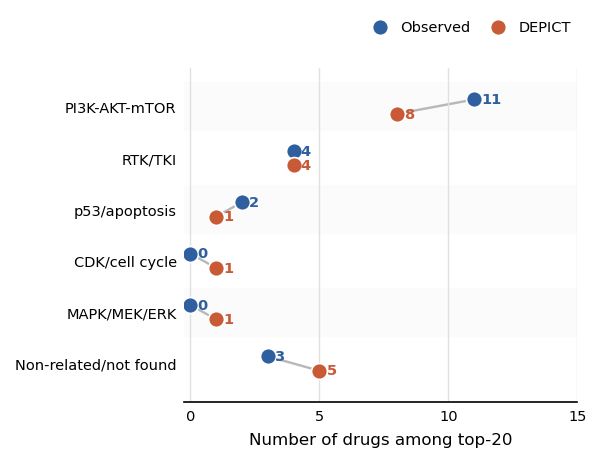

Displayed and saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/figures/figure2/fig2d_left_top20_moa_composition_polished.pdf


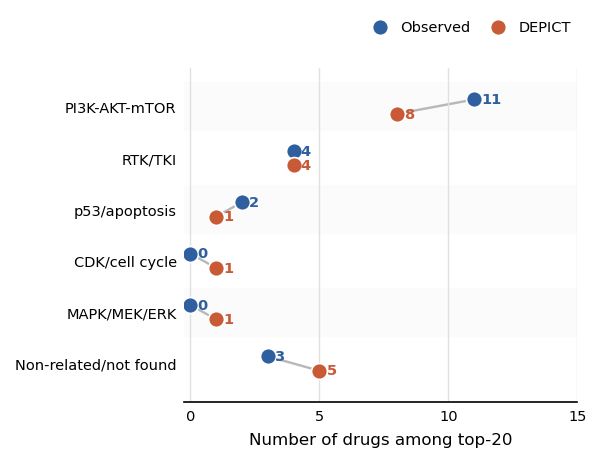

In [8]:
# %%
# Figure 2D-left: publication-style paired dot plot of broad MoA composition.
# Dots are vertically dodged so observed and DEPICT points remain visible
# even when counts are identical.

moa_counts = (
    selected_top
    .assign(
        broad_moa_class=lambda d: pd.Categorical(
            d["broad_moa_class"],
            categories=MOA_CLASSES_FOR_2D_LEFT,
            ordered=True,
        )
    )
    .groupby(["broad_moa_class", "source"], observed=False)
    .size()
    .reset_index(name="n_drugs")
)

moa_counts["fraction_top20"] = moa_counts["n_drugs"] / float(TOP_N)
moa_counts.to_csv(
    TABLE_DIR / "fig2d_left_top20_moa_composition_counts.csv",
    index=False,
)

plot_moa = moa_counts.copy()
plot_moa["broad_moa_class"] = pd.Categorical(
    plot_moa["broad_moa_class"],
    categories=MOA_CLASSES_FOR_2D_LEFT,
    ordered=True,
)
plot_moa = (
    plot_moa
    .sort_values(["broad_moa_class", "source"])
    .reset_index(drop=True)
)

y_base = np.arange(len(MOA_CLASSES_FOR_2D_LEFT))
y_map = {m: i for i, m in enumerate(MOA_CLASSES_FOR_2D_LEFT)}

# Small vertical offset prevents identical counts from overlapping.
y_dodge = {
    "Observed LINCS": -0.14,
    "DEPICT-predicted LINCS": 0.14,
}

# Original width was 5.4 with x-axis maximum 20.
# New width preserves the same horizontal scale:
# 5.4 × 15 / 20 = 4.05.
fig, ax = plt.subplots(figsize=(4.05, 3.1))

# Alternating row guides.
for yi in y_base:
    ax.axhspan(
        yi - 0.46,
        yi + 0.46,
        color=("0.985" if yi % 2 == 0 else "1.0"),
        zorder=0,
    )

# Connector lines between observed and DEPICT counts.
for moa in MOA_CLASSES_FOR_2D_LEFT:
    vals = {
        row["source"]: row["n_drugs"]
        for _, row in plot_moa[
            plot_moa["broad_moa_class"] == moa
        ].iterrows()
    }

    if all(source in vals for source in SOURCE_ORDER):
        ax.plot(
            [
                vals["Observed LINCS"],
                vals["DEPICT-predicted LINCS"],
            ],
            [
                y_map[moa] + y_dodge["Observed LINCS"],
                y_map[moa] + y_dodge["DEPICT-predicted LINCS"],
            ],
            color="0.72",
            lw=1.15,
            zorder=1,
        )

# Plot source-specific points and count labels.
for source in SOURCE_ORDER:
    sub = plot_moa[plot_moa["source"] == source].copy()

    y = (
        sub["broad_moa_class"]
        .map(y_map)
        .astype(float)
        + y_dodge[source]
    )

    ax.scatter(
        sub["n_drugs"],
        y,
        s=58,
        color=SOURCE_COLORS[source],
        edgecolor="white",
        linewidth=0.8,
        label=SOURCE_SHORT[source],
        zorder=3,
    )

    for xi, yi, count in zip(
        sub["n_drugs"],
        y,
        sub["n_drugs"],
    ):
        ax.text(
            xi + 0.28,
            yi,
            str(int(count)),
            va="center",
            ha="left",
            fontsize=7,
            color=SOURCE_COLORS[source],
            fontweight="bold",
        )

ax.set_yticks(y_base)
ax.set_yticklabels(MOA_CLASSES_FOR_2D_LEFT)

# Requested x-axis range.
ax.set_xlim(-0.25, 15)
ax.set_xticks(np.arange(0, 16, 5))

ax.set_xlabel(f"Number of drugs among top-{TOP_N}")
ax.grid(axis="x", color="0.88", lw=0.65)
ax.tick_params(axis="both", length=0)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.invert_yaxis()

# Place the legend above the upper-right corner.
# This preserves the requested top-right position while avoiding all data points.
ax.legend(
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.16),
    ncol=2,
    handletextpad=0.4,
    columnspacing=0.9,
    borderaxespad=0.0,
)

# Reserve vertical space for the legend without changing figure height.
fig.subplots_adjust(
    left=0.36,
    right=0.98,
    bottom=0.17,
    top=0.84,
)

save_figure(
    fig,
    "fig2d_left_top20_moa_composition_polished",
    show=True,
)

## Figure 2C-style drug-level clinical-phase map

This is a replot of the candidate-level map layout using the shared observed-predicted drug universe for both source rankings. The color label is `clinical_phase` from Drug Repurposing Hub metadata, not manual NSCLC evidence. Therefore this panel should be interpreted as **general drug-development status**, not NSCLC-specific clinical evidence.

Number of unique drugs displayed: 35


,drug_key,pert_iname,clinical_phase_label,clinical_phase_raw,observed_rank_top20,depict_rank_top20
0,dasatinib,dasatinib,Launched/approved,Launched,NaN,9.0
1,midostaurin,midostaurin,Launched/approved,Launched,NaN,11.0
2,quinacrine,mepacrine,Launched/approved,Launched,14.0,NaN
3,crizotinib,crizotinib,Launched/approved,Launched,15.0,NaN
4,sirolimus,sirolimus,Launched/approved,Launched,19.0,NaN
5,dactolisib,NVP-BEZ235,Phase 3,Phase 3,2.0,13.0
6,dovitinib,dovitinib,Phase 3,Phase 3,13.0,NaN
7,mk2206,MK-2206,Phase 2,Phase 2,NaN,2.0
8,pictilisib,GDC-0941,Phase 2,Phase 2,4.0,NaN
9,zstk474,ZSTK-474,Phase 2,Phase 1/Phase 2,17.0,5.0


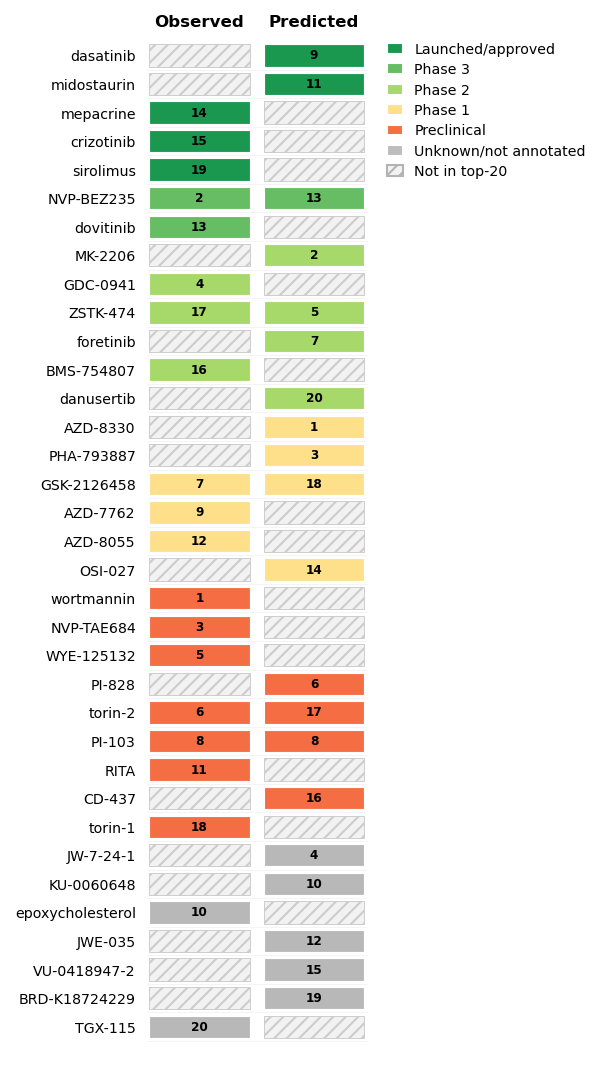

Displayed and saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/figures/figure2/fig2c_shared_top20_clinical_phase_map_publication_style.pdf


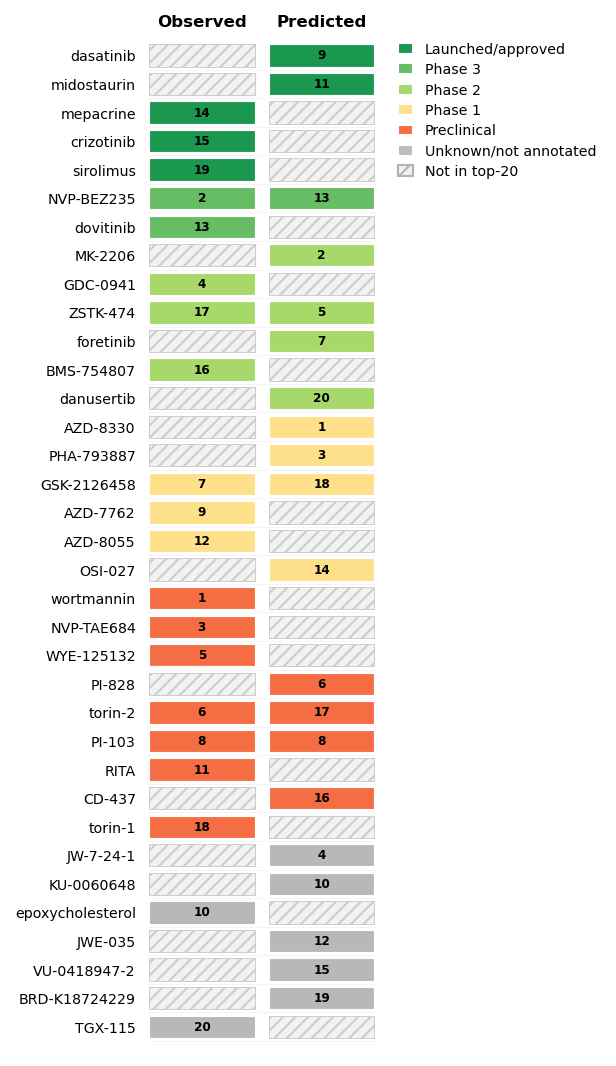

In [9]:
# %%
# Figure 2C-style drug-level clinical-phase map.
# Publication-style tile map following the earlier clean PDF layout,
# but using the current logic:
#   1) shared observed-predicted drug universe
#   2) observed top-20 and DEPICT top-20 from shared universe
#   3) clinical_phase from Drug Repurposing Hub drug_meta
#   4) no manual NSCLC evidence labels

from IPython.display import display
from matplotlib.patches import Rectangle
from matplotlib.patches import Patch

# ---------------------------------------------------------------------
# Build top-20 union table.
# ---------------------------------------------------------------------
obs_top_map = observed_top.copy()
pred_top_map = predicted_top.copy()

obs_top_map["source"] = "Observed"
pred_top_map["source"] = "DEPICT"

required_cols = [
    "drug_key",
    "pert_iname",
    "rank",
    "source",
    "clinical_phase_label",
    "clinical_phase_raw",
]

candidate_rows = pd.concat(
    [
        obs_top_map[required_cols],
        pred_top_map[required_cols],
    ],
    ignore_index=True,
)

# One display name per normalized drug key.
display_name = (
    candidate_rows
    .drop_duplicates("drug_key", keep="first")
    .set_index("drug_key")["pert_iname"]
    .to_dict()
)

# Rank table: one row per drug, columns = observed / DEPICT top-20 rank.
rank_wide = candidate_rows.pivot_table(
    index="drug_key",
    columns="source",
    values="rank",
    aggfunc="min",
)

# Clinical phase is drug-level metadata, so use one label per drug.
phase_by_drug = (
    candidate_rows
    .drop_duplicates("drug_key", keep="first")
    .set_index("drug_key")["clinical_phase_label"]
    .to_dict()
)

phase_raw_by_drug = (
    candidate_rows
    .drop_duplicates("drug_key", keep="first")
    .set_index("drug_key")["clinical_phase_raw"]
    .to_dict()
)

# ---------------------------------------------------------------------
# Order rows like the previous evidence-map style:
# higher clinical-development status first, then best rank.
# ---------------------------------------------------------------------
phase_sort_order = {
    "Launched/approved": 0,
    "Phase 3": 1,
    "Phase 2": 2,
    "Phase 1": 3,
    "Preclinical": 4,
    "Unknown/not annotated": 5,
    "Not in top-20": 6,
}

row_order_df = rank_wide.copy()
row_order_df["best_rank"] = row_order_df[["Observed", "DEPICT"]].min(axis=1)
row_order_df["clinical_phase_label"] = [
    phase_by_drug.get(k, "Unknown/not annotated") for k in row_order_df.index
]
row_order_df["phase_sort"] = row_order_df["clinical_phase_label"].map(phase_sort_order).fillna(5).astype(int)
row_order_df["display_name"] = [display_name.get(k, k) for k in row_order_df.index]

row_order_df = row_order_df.sort_values(
    ["phase_sort", "best_rank", "display_name"],
    ascending=[True, True, True],
)

drug_order = row_order_df.index.tolist()

# Save the exact plotted table.
clinical_map_records = []
for drug_key in drug_order:
    clinical_map_records.append({
        "drug_key": drug_key,
        "pert_iname": display_name.get(drug_key, drug_key),
        "clinical_phase_label": phase_by_drug.get(drug_key, "Unknown/not annotated"),
        "clinical_phase_raw": phase_raw_by_drug.get(drug_key, np.nan),
        "observed_rank_top20": (
            rank_wide.loc[drug_key, "Observed"]
            if "Observed" in rank_wide.columns and pd.notna(rank_wide.loc[drug_key, "Observed"])
            else np.nan
        ),
        "depict_rank_top20": (
            rank_wide.loc[drug_key, "DEPICT"]
            if "DEPICT" in rank_wide.columns and pd.notna(rank_wide.loc[drug_key, "DEPICT"])
            else np.nan
        ),
    })

clinical_map_table = pd.DataFrame(clinical_map_records)
clinical_map_table.to_csv(
    TABLE_DIR / "fig2c_shared_top20_clinical_phase_map_table.csv",
    index=False,
)

print("Number of unique drugs displayed:", len(drug_order))
display(clinical_map_table.head(10))


# ---------------------------------------------------------------------
# Helper functions for tile values.
# ---------------------------------------------------------------------
def tile_phase(drug_key, source):
    """Clinical-phase color for a tile. Missing tile means not in that source top-20."""
    if source in rank_wide.columns and pd.notna(rank_wide.loc[drug_key, source]):
        return phase_by_drug.get(drug_key, "Unknown/not annotated")
    return "Not in top-20"


def tile_rank(drug_key, source):
    """Rank text shown inside a tile."""
    if source in rank_wide.columns and pd.notna(rank_wide.loc[drug_key, source]):
        return str(int(rank_wide.loc[drug_key, source]))
    return ""


# ---------------------------------------------------------------------
# Plot: old clean two-column tile style.
# ---------------------------------------------------------------------
plot_sources = ["Observed", "DEPICT"]
source_headers = {
    "Observed": "Observed",
    "DEPICT": "Predicted",
}

fig_h = max(5.0, 0.17 * len(drug_order) + 1.20)
fig, ax = plt.subplots(figsize=(4.15, fig_h))

# Geometry tuned to mimic the earlier PDF style.
tile_w = 0.88
tile_h = 0.78
x_positions = {
    "Observed": 0.0,
    "DEPICT": 1.0,
}

ax.set_xlim(-0.05, 1.95)
ax.set_ylim(-0.65, len(drug_order) - 0.15)

for yi, drug_key in enumerate(drug_order):
    for source in plot_sources:
        x0 = x_positions[source]
        phase = tile_phase(drug_key, source)
        rank_text = tile_rank(drug_key, source)

        if phase == "Not in top-20":
            facecolor = CLINICAL_PHASE_COLORS.get("Not in top-20", "#F4F4F4")
            edgecolor = "0.80"
            hatch = "////"
            lw = 0.45
        else:
            facecolor = CLINICAL_PHASE_COLORS.get(phase, "#B8B8B8")
            edgecolor = "white"
            hatch = None
            lw = 0.55

        rect = Rectangle(
            (x0, yi - tile_h / 2),
            tile_w,
            tile_h,
            facecolor=facecolor,
            edgecolor=edgecolor,
            linewidth=lw,
            hatch=hatch,
        )
        ax.add_patch(rect)

        if rank_text:
            ax.text(
                x0 + tile_w / 2,
                yi,
                rank_text,
                ha="center",
                va="center",
                fontsize=5.8,
                fontweight="bold",
                color="black",
            )

# Y-axis drug labels.
ax.set_yticks(np.arange(len(drug_order)))
ax.set_yticklabels(
    [display_name.get(k, k) for k in drug_order],
    fontsize=6.8,
)

# X-axis source headers.
ax.set_xticks([x_positions[s] + tile_w / 2 for s in plot_sources])
ax.set_xticklabels(
    [source_headers[s] for s in plot_sources],
    fontsize=8.0,
    fontweight="bold",
)
ax.xaxis.tick_top()

# Match the previous map: first row at the top.
ax.invert_yaxis()

# Clean frame.
ax.tick_params(axis="both", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Light row guides between groups for readability.
for y in np.arange(len(drug_order)) + 0.5:
    ax.hlines(
        y,
        -0.02,
        1.90,
        color="0.94",
        linewidth=0.35,
        zorder=0,
    )

# Legend: keep it compact and journal-style.
legend_order = [
    "Launched/approved",
    "Phase 3",
    "Phase 2",
    "Phase 1",
    "Preclinical",
    "Unknown/not annotated",
]

legend_handles = [
    Patch(
        facecolor=CLINICAL_PHASE_COLORS[p],
        edgecolor="white",
        label=p,
    )
    for p in legend_order
    if p in CLINICAL_PHASE_COLORS
]

legend_handles.append(
    Patch(
        facecolor=CLINICAL_PHASE_COLORS.get("Not in top-20", "#F4F4F4"),
        edgecolor="0.70",
        hatch="////",
        label="Not in top-20",
    )
)

ax.legend(
    handles=legend_handles,
    frameon=False,
    bbox_to_anchor=(1.04, 1.0),
    loc="upper left",
    borderaxespad=0.0,
    labelspacing=0.45,
    handlelength=1.1,
    handleheight=0.8,
    fontsize=6.8,
)

fig.tight_layout()

# Display in notebook cell and also save.
display(fig)
save_figure(fig, "fig2c_shared_top20_clinical_phase_map_publication_style", show=False)

In [10]:

# %%
def make_match_keys(df):
    out = df.copy()
    if "obs_name" in out.columns:
        out["obs_name_key"] = out["obs_name"].astype(str)
    if "pert_iname" in out.columns:
        out["drug_key"] = out["pert_iname"].map(normalize_drug_name)
    if "dose" in out.columns:
        out["dose_key"] = pd.to_numeric(out["dose"], errors="coerce").round(8).astype(str)
    if "pert_time" in out.columns:
        out["pert_time_key"] = pd.to_numeric(out["pert_time"], errors="coerce").round(8).astype(str)
    return out


def _collapse_dge_for_merge(dge, merge_cols, gene_cols, strategy):
    """Prepare a DGE table for merging.

    For obs_name, duplicate rows should not exist; keep first.
    For profile-level fallback keys, average duplicates so each selected
    drug-condition maps to one DGE vector.
    """
    dge_small = dge[merge_cols + gene_cols].copy()
    if strategy == "obs_name":
        return dge_small.drop_duplicates(merge_cols, keep="first")
    return dge_small.groupby(merge_cols, as_index=False, sort=False)[gene_cols].mean()


def _try_attach_with_keys(sel, dge, merge_cols, gene_cols, strategy):
    dge_small = _collapse_dge_for_merge(dge, merge_cols, gene_cols, strategy)
    merged = sel.merge(dge_small, on=merge_cols, how="left", validate="m:1")
    missing = merged[gene_cols].isna().all(axis=1)
    match_rate = 1.0 - float(missing.mean()) if len(missing) else 0.0
    return merged, match_rate


def attach_dge_profiles(selected, dge_df, source_label):
    """Attach DGE rows to selected ranking rows.

    Matching order:
    1) obs_name, if it actually matches;
    2) pert_iname + dose + pert_time, when both tables contain dose;
    3) pert_iname + pert_time, useful for observed tables that do not store dose;
    4) pert_iname only, as a last-resort average across available profiles.

    This fallback is important because the observed and predicted DGE files may
    not preserve the same obs_name namespace as the screening-rank table.
    """
    sel = selected[selected["source"] == source_label].copy()
    dge = make_match_keys(dge_df)
    sel = make_match_keys(sel)

    gene_cols = [c for c in common_gene_cols if c in dge.columns]
    if not gene_cols:
        raise ValueError(f"No common gene columns found in DGE table for {source_label}.")

    candidate_strategies = []
    if "obs_name_key" in sel.columns and "obs_name_key" in dge.columns:
        candidate_strategies.append(("obs_name", ["obs_name_key"]))
    if {"drug_key", "dose_key", "pert_time_key"}.issubset(sel.columns) and {"drug_key", "dose_key", "pert_time_key"}.issubset(dge.columns):
        candidate_strategies.append(("drug_dose_time", ["drug_key", "dose_key", "pert_time_key"]))
    if {"drug_key", "pert_time_key"}.issubset(sel.columns) and {"drug_key", "pert_time_key"}.issubset(dge.columns):
        candidate_strategies.append(("drug_time", ["drug_key", "pert_time_key"]))
    if "drug_key" in sel.columns and "drug_key" in dge.columns:
        candidate_strategies.append(("drug_only_average", ["drug_key"]))

    if not candidate_strategies:
        raise ValueError(
            f"Cannot match {source_label} selected rows to DGE table. "
            "Need obs_name or pert_iname with dose/time metadata."
        )

    tried = []
    best_merged = None
    best_rate = -1.0
    best_strategy = None
    best_merge_cols = None

    for strategy, merge_cols in candidate_strategies:
        merged_try, match_rate = _try_attach_with_keys(sel, dge, merge_cols, gene_cols, strategy)
        tried.append({"source": source_label, "strategy": strategy, "merge_cols": ",".join(merge_cols), "match_rate": match_rate})
        if match_rate > best_rate:
            best_merged = merged_try
            best_rate = match_rate
            best_strategy = strategy
            best_merge_cols = merge_cols
        if match_rate == 1.0:
            break

    diagnostics = pd.DataFrame(tried)
    diagnostics.to_csv(TABLE_DIR / f"fig2d_{SOURCE_SHORT[source_label].lower()}_dge_matching_diagnostics.csv", index=False)

    merged = best_merged.copy()
    merged["matched_dge_strategy"] = best_strategy
    merged["matched_dge_rate_for_source"] = best_rate

    missing_profile = merged[gene_cols].isna().all(axis=1)
    print(f"{source_label}: selected DGE match strategy = {best_strategy}; match rate = {best_rate:.3f}")
    print(diagnostics)

    if missing_profile.any():
        display_cols = [c for c in ["pert_iname", "rank", "dose", "pert_time", "obs_name"] if c in merged.columns]
        print(f"WARNING: {missing_profile.sum()} {source_label} selected rows still did not match a DGE profile.")
        print(merged.loc[missing_profile, display_cols])
    return merged


obs_profiles = attach_dge_profiles(selected_top_2d, df_diffexp_obs, "Observed LINCS")
pred_profiles = attach_dge_profiles(selected_top_2d, df_diffexp_pred, "DEPICT-predicted LINCS")
profiles = pd.concat([obs_profiles, pred_profiles], ignore_index=True)
profiles.to_csv(TABLE_DIR / "fig2d_selected_top20_profiles_with_dge_metadata.csv", index=False)
print("Matched selected profiles:", profiles.shape)
profiles[[c for c in ["source", "rank", "pert_iname", "broad_moa_class", "reverse_score", "matched_dge_strategy"] if c in profiles.columns]].head()


Observed LINCS: selected DGE match strategy = obs_name; match rate = 1.000
           source  strategy    merge_cols  match_rate
0  Observed LINCS  obs_name  obs_name_key         1.0
DEPICT-predicted LINCS: selected DGE match strategy = drug_time; match rate = 1.000
                   source   strategy              merge_cols  match_rate
0  DEPICT-predicted LINCS   obs_name            obs_name_key         0.0
1  DEPICT-predicted LINCS  drug_time  drug_key,pert_time_key         1.0
Matched selected profiles: (27, 996)


,source,rank,pert_iname,broad_moa_class,reverse_score,matched_dge_strategy
0,Observed LINCS,1,wortmannin,PI3K-AKT-mTOR,0.839986,obs_name
1,Observed LINCS,2,NVP-BEZ235,PI3K-AKT-mTOR,0.820359,obs_name
2,Observed LINCS,3,NVP-TAE684,RTK/TKI,0.767374,obs_name
3,Observed LINCS,4,GDC-0941,PI3K-AKT-mTOR,0.756509,obs_name
4,Observed LINCS,5,WYE-125132,PI3K-AKT-mTOR,0.747868,obs_name


In [11]:
# %%
# Calculate NSCLC disease pathway direction from tumor-vs-normal log2FC.
# Important: run GSEA on the full disease-score ranking, not on pathway genes only.
# This matches the Analysis 3 preranked scoring logic and avoids the all-hit/undefined case.
disease_pathway_es = {}
for pathway, genes in gmt_matched.items():
    disease_pathway_es[pathway] = signed_preranked_es(
        disease_score,
        genes,
        weight_exponent=GSEA_WEIGHT_EXPONENT,
        min_overlap=MIN_LANDMARK_OVERLAP,
    )

disease_pathway_df = pd.DataFrame({
    "pathway_raw": list(disease_pathway_es.keys()),
    "pathway_display": [PATHWAY_RENAME.get(k, k) for k in disease_pathway_es.keys()],
    "disease_signed_es_tumor_vs_normal": list(disease_pathway_es.values()),
    "gsea_weight_exponent": GSEA_WEIGHT_EXPONENT,
    "tie_rule": GSEA_TIE_RULE,
    "min_landmark_overlap": MIN_LANDMARK_OVERLAP,
})
disease_pathway_df["disease_direction_sign"] = np.sign(disease_pathway_df["disease_signed_es_tumor_vs_normal"])
disease_pathway_df.to_csv(TABLE_DIR / "fig2d_nsclc_disease_pathway_direction.csv", index=False)
disease_pathway_df


,pathway_raw,pathway_display,disease_signed_es_tumor_vs_normal,gsea_weight_exponent,tie_rule,min_landmark_overlap,disease_direction_sign
0,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,0.368016,1.0,stable_mergesort_descending_signed_dge,10,1.0
1,HALLMARK_MTORC1_SIGNALING,mTORC1,0.551416,1.0,stable_mergesort_descending_signed_dge,10,1.0
2,HALLMARK_E2F_TARGETS,E2F targets,0.774137,1.0,stable_mergesort_descending_signed_dge,10,1.0
3,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,0.781661,1.0,stable_mergesort_descending_signed_dge,10,1.0
4,HALLMARK_DNA_REPAIR,DNA repair,0.575699,1.0,stable_mergesort_descending_signed_dge,10,1.0
5,HALLMARK_APOPTOSIS,Apoptosis,0.272375,1.0,stable_mergesort_descending_signed_dge,10,1.0
6,REACTOME_MAPK_FAMILY_SIGNALING_CASCADES,MAPK cascades,0.234399,1.0,stable_mergesort_descending_signed_dge,10,1.0
7,REACTOME_EGFR_ERBB_FAMILY_SIGNALING,EGFR/ERBB,0.234192,1.0,stable_mergesort_descending_signed_dge,10,1.0
8,REACTOME_CHROMATIN_MODIFYING_ENZYMES,Chromatin modifiers,0.593260,1.0,stable_mergesort_descending_signed_dge,10,1.0
9,REACTOME_CHROMATIN_ORGANIZATION,Chromatin organization,0.495476,1.0,stable_mergesort_descending_signed_dge,10,1.0


In [12]:
# %%
# Calculate drug signed ES and pathway-reversal score.
# Drug ES uses the same deterministic signed weighted preranked GSEA implementation as Analysis 3.
gene_cols = [c for c in common_gene_cols if c in profiles.columns]
pathway_records = []

for i, row in profiles.iterrows():
    drug_scores = row[gene_cols].astype(float)
    for pathway, genes in gmt_matched.items():
        drug_es = signed_preranked_es(
            drug_scores,
            genes,
            weight_exponent=GSEA_WEIGHT_EXPONENT,
            min_overlap=MIN_LANDMARK_OVERLAP,
        )
        disease_es = disease_pathway_es.get(pathway, np.nan)
        disease_sign = np.sign(disease_es) if pd.notna(disease_es) and disease_es != 0 else np.nan
        reversal = -disease_sign * drug_es if pd.notna(disease_sign) and pd.notna(drug_es) else np.nan
        pathway_records.append({
            "source": row["source"],
            "rank": row["rank"],
            "pert_iname": row["pert_iname"],
            "drug_key": row["drug_key"],
            "broad_moa_class": row["broad_moa_class"],
            "reverse_score": row["reverse_score"],
            "pathway_raw": pathway,
            "pathway_display": PATHWAY_RENAME.get(pathway, pathway),
            "drug_signed_es": drug_es,
            "disease_signed_es_tumor_vs_normal": disease_es,
            "pathway_reversal_score": reversal,
            "gsea_weight_exponent": GSEA_WEIGHT_EXPONENT,
            "tie_rule": GSEA_TIE_RULE,
            "min_landmark_overlap": MIN_LANDMARK_OVERLAP,
        })

pathway_scores = pd.DataFrame(pathway_records)
pathway_scores.to_csv(TABLE_DIR / "fig2d_drug_level_pathway_reversal_scores.csv", index=False)
print(pathway_scores.shape)
pathway_scores.head()


(270, 14)


,source,rank,pert_iname,drug_key,broad_moa_class,reverse_score,pathway_raw,pathway_display,drug_signed_es,disease_signed_es_tumor_vs_normal,pathway_reversal_score,gsea_weight_exponent,tie_rule,min_landmark_overlap
0,Observed LINCS,1,wortmannin,wortmannin,PI3K-AKT-mTOR,0.839986,HALLMARK_PI3K_AKT_MTOR_SIGNALING,PI3K/AKT/mTOR,-0.236433,0.368016,0.236433,1.0,stable_mergesort_descending_signed_dge,10
1,Observed LINCS,1,wortmannin,wortmannin,PI3K-AKT-mTOR,0.839986,HALLMARK_MTORC1_SIGNALING,mTORC1,-0.497741,0.551416,0.497741,1.0,stable_mergesort_descending_signed_dge,10
2,Observed LINCS,1,wortmannin,wortmannin,PI3K-AKT-mTOR,0.839986,HALLMARK_E2F_TARGETS,E2F targets,-0.819982,0.774137,0.819982,1.0,stable_mergesort_descending_signed_dge,10
3,Observed LINCS,1,wortmannin,wortmannin,PI3K-AKT-mTOR,0.839986,HALLMARK_G2M_CHECKPOINT,G2M checkpoint,-0.816125,0.781661,0.816125,1.0,stable_mergesort_descending_signed_dge,10
4,Observed LINCS,1,wortmannin,wortmannin,PI3K-AKT-mTOR,0.839986,HALLMARK_DNA_REPAIR,DNA repair,-0.525334,0.575699,0.525334,1.0,stable_mergesort_descending_signed_dge,10


In [13]:

# %%
# Class centroids: mean pathway-reversal vector within each MoA class and source.
centroid = (
    pathway_scores
    .dropna(subset=["pathway_reversal_score"])
    .groupby(["broad_moa_class", "source", "pathway_display"], as_index=False)
    .agg(
        mean_pathway_reversal=("pathway_reversal_score", "mean"),
        n_drugs=("pert_iname", "nunique"),
    )
)
centroid.to_csv(TABLE_DIR / "fig2d_class_source_pathway_reversal_centroids_long.csv", index=False)

centroid_wide = centroid.pivot_table(
    index=["broad_moa_class", "source"],
    columns="pathway_display",
    values="mean_pathway_reversal",
)
centroid_wide = centroid_wide.reindex(columns=[p for p in PATHWAY_DISPLAY_ORDER if p in centroid_wide.columns])

# Build paired row order and labels for the observed-vs-DEPICT paired heatmap.
row_index = []
row_labels = []
for moa in MOA_CLASSES_FOR_2D_RIGHT:
    for source in SOURCE_ORDER:
        idx = (moa, source)
        if idx in centroid_wide.index:
            n = int(centroid[(centroid["broad_moa_class"] == moa) & (centroid["source"] == source)]["n_drugs"].max())
            row_index.append(idx)
            row_labels.append(f"{moa} | {SOURCE_SHORT[source]} (n={n})")
centroid_wide = centroid_wide.reindex(row_index)
centroid_wide.to_csv(TABLE_DIR / "fig2d_class_source_pathway_reversal_centroids_wide.csv")

# Also build source-specific matrices with the same row/column space.
def build_source_centroid_matrix(source_label):
    mat = (
        centroid[centroid["source"] == source_label]
        .pivot_table(index="broad_moa_class", columns="pathway_display", values="mean_pathway_reversal")
        .reindex(index=MOA_CLASSES_FOR_2D_RIGHT)
        .reindex(columns=[p for p in PATHWAY_DISPLAY_ORDER if p in centroid_wide.columns])
    )
    n_by_class = (
        centroid[centroid["source"] == source_label]
        .groupby("broad_moa_class")["n_drugs"]
        .max()
        .reindex(MOA_CLASSES_FOR_2D_RIGHT)
        .fillna(0)
        .astype(int)
    )
    return mat, n_by_class

observed_centroid_matrix, observed_n_by_class = build_source_centroid_matrix("Observed LINCS")
predicted_centroid_matrix, predicted_n_by_class = build_source_centroid_matrix("DEPICT-predicted LINCS")

observed_centroid_matrix.to_csv(TABLE_DIR / "fig2d_observed_only_class_pathway_reversal_centroids_wide.csv")
predicted_centroid_matrix.to_csv(TABLE_DIR / "fig2d_predicted_only_class_pathway_reversal_centroids_wide.csv")

print("Centroid rows in paired comparison:", centroid_wide.shape[0])
print("Observed-only matrix shape:", observed_centroid_matrix.shape)
print("Predicted-only matrix shape:", predicted_centroid_matrix.shape)
display(centroid_wide)


Centroid rows in paired comparison: 4
Observed-only matrix shape: (2, 10)
Predicted-only matrix shape: (2, 10)


pathway_display                         PI3K/AKT/mTOR    mTORC1  EGFR/ERBB  \
broad_moa_class source                                                       
PI3K-AKT-mTOR   Observed LINCS               0.085693  0.480745  -0.180225   
                DEPICT-predicted LINCS      -0.069713  0.414855  -0.388998   
RTK/TKI         Observed LINCS               0.040767  0.401383  -0.121678   
                DEPICT-predicted LINCS      -0.001238  0.360706  -0.295415   

pathway_display                         MAPK cascades  E2F targets  \
broad_moa_class source                                               
PI3K-AKT-mTOR   Observed LINCS              -0.150483     0.768853   
                DEPICT-predicted LINCS      -0.232980     0.522137   
RTK/TKI         Observed LINCS              -0.113795     0.792274   
                DEPICT-predicted LINCS      -0.088974     0.358816   

pathway_display                         G2M checkpoint  DNA repair  Apoptosis  \
broad_moa_class source                                                          
PI3K-AKT-mTOR   Observed LINCS                0.767478    0.566965   0.076199   
                DEPICT-predicted LINCS        0.555185    0.492007  -0.293773   
RTK/TKI         Observed LINCS                0.788589    0.512153  -0.009440   
                DEPICT-predicted LINCS        0.535722    0.274893  -0.131967   

pathway_display                         Chromatin modifiers  \
broad_moa_class source                                        
PI3K-AKT-mTOR   Observed LINCS                     0.357479   
                DEPICT-predicted LINCS             0.020817   
RTK/TKI         Observed LINCS                     0.344652   
                DEPICT-predicted LINCS            -0.148241   

pathway_display                         Chromatin organization  
broad_moa_class source                                          
PI3K-AKT-mTOR   Observed LINCS                        0.324641  
                DEPICT-predicted LINCS                0.100824  
RTK/TKI         Observed LINCS                        0.311677  
                DEPICT-predicted LINCS                0.011442

In [14]:

# %%
# Spearman correlation between observed and DEPICT class-centroid pathway vectors.
corr_columns = [
    "broad_moa_class",
    "spearman_rho_observed_vs_depict_centroid",
    "p_value",
    "n_pathways",
    "n_observed_drugs",
    "n_depict_drugs",
]
corr_records = []
for moa in MOA_CLASSES_FOR_2D_RIGHT:
    obs_idx = (moa, "Observed LINCS")
    pred_idx = (moa, "DEPICT-predicted LINCS")
    obs_available = obs_idx in centroid_wide.index
    pred_available = pred_idx in centroid_wide.index

    n_obs = int(
        centroid[(centroid["broad_moa_class"] == moa) & (centroid["source"] == "Observed LINCS")]["n_drugs"].max()
    ) if ((centroid["broad_moa_class"] == moa) & (centroid["source"] == "Observed LINCS")).any() else 0
    n_pred = int(
        centroid[(centroid["broad_moa_class"] == moa) & (centroid["source"] == "DEPICT-predicted LINCS")]["n_drugs"].max()
    ) if ((centroid["broad_moa_class"] == moa) & (centroid["source"] == "DEPICT-predicted LINCS")).any() else 0

    if obs_available and pred_available:
        obs_vec = centroid_wide.loc[obs_idx]
        pred_vec = centroid_wide.loc[pred_idx]
        valid = obs_vec.notna() & pred_vec.notna()
        if valid.sum() >= 3 and n_obs >= MIN_DRUGS_PER_CLASS_FOR_CORRELATION and n_pred >= MIN_DRUGS_PER_CLASS_FOR_CORRELATION:
            rho, pval = spearmanr(obs_vec[valid], pred_vec[valid])
        else:
            rho, pval = np.nan, np.nan
        n_pathways = int(valid.sum())
    else:
        rho, pval, n_pathways = np.nan, np.nan, 0

    corr_records.append({
        "broad_moa_class": moa,
        "spearman_rho_observed_vs_depict_centroid": rho,
        "p_value": pval,
        "n_pathways": n_pathways,
        "n_observed_drugs": n_obs,
        "n_depict_drugs": n_pred,
    })

class_corr = pd.DataFrame(corr_records, columns=corr_columns)
class_corr.to_csv(TABLE_DIR / "fig2d_class_centroid_observed_vs_depict_spearman.csv", index=False)
class_corr


,broad_moa_class,spearman_rho_observed_vs_depict_centroid,p_value,n_pathways,n_observed_drugs,n_depict_drugs
0,PI3K-AKT-mTOR,0.963636,0.000007,10,11,8
1,RTK/TKI,0.806061,0.004862,10,4,4


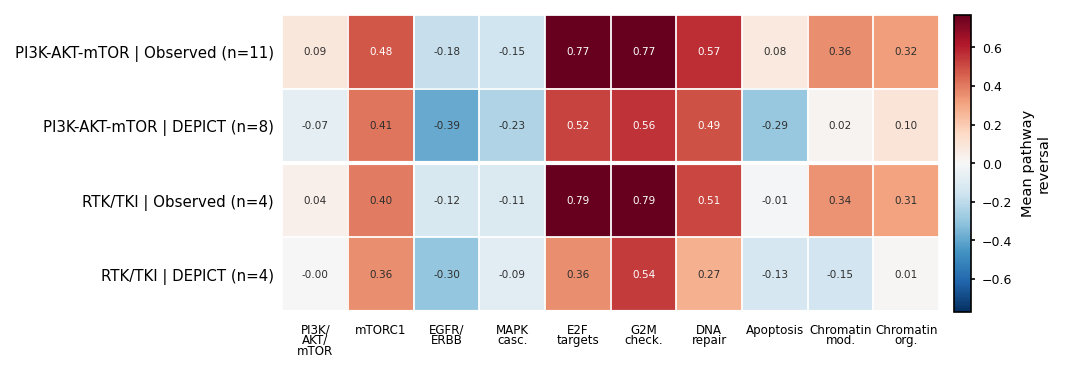

/tmp/ipykernel_562300/118646783.py:312: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Displayed and saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/figures/figure2/fig2d_right_paired_class_source_pathway_reversal_heatmap_polished.pdf


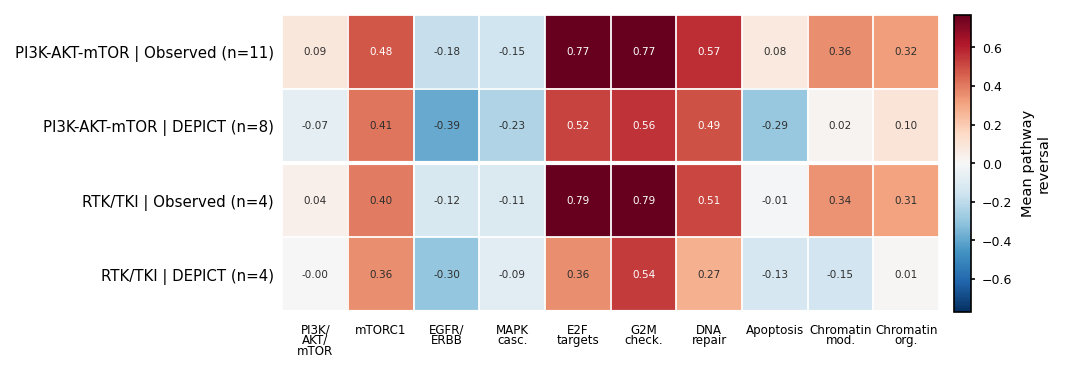

In [15]:
# %%
# Figure 2D-right: compact paired heatmap for the main MoA classes.
# Rows pair Observed and DEPICT within each MoA class; columns are compact pathway labels.

from IPython.display import display
import textwrap

mat = centroid_wide.to_numpy(dtype=float)
finite_vals = mat[np.isfinite(mat)]
color_lim = np.nanpercentile(np.abs(finite_vals), 95) if finite_vals.size else 1.0
color_lim = max(color_lim, 1e-6)

# More compact, manually wrapped labels.
# The two chromatin labels are intentionally abbreviated to avoid overlap.
HEATMAP_PATHWAY_LABELS = {
    "PI3K/AKT/mTOR": "PI3K/\nAKT/\nmTOR",
    "mTORC1": "mTORC1",
    "EGFR/ERBB": "EGFR/\nERBB",
    "MAPK cascades": "MAPK\ncasc.",
    "E2F targets": "E2F\ntargets",
    "G2M checkpoint": "G2M\ncheck.",
    "DNA repair": "DNA\nrepair",
    "Apoptosis": "Apoptosis",
    "Chromatin modifiers": "Chromatin\nmod.",
    "Chromatin organization": "Chromatin\norg.",
}

def compact_pathway_label(label, width=9):
    """Fallback wrapper for any pathway not manually specified."""
    if label in HEATMAP_PATHWAY_LABELS:
        return HEATMAP_PATHWAY_LABELS[label]
    return "\n".join(textwrap.wrap(str(label), width=width, break_long_words=False))

short_cols = [compact_pathway_label(c) for c in centroid_wide.columns]

# Slightly wider figure and slightly more bottom space for multi-line labels.
fig = plt.figure(figsize=(6.95, max(2.55, 0.38 * centroid_wide.shape[0] + 1.35)))
gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[22, 0.55],
    wspace=0.045,
)

ax = fig.add_subplot(gs[0, 0])
cax = fig.add_subplot(gs[0, 1])

im = ax.imshow(
    mat,
    aspect="auto",
    cmap="RdBu_r",
    vmin=-color_lim,
    vmax=color_lim,
)

ax.set_xticks(np.arange(centroid_wide.shape[1]))
ax.set_xticklabels(
    short_cols,
    rotation=0,
    ha="center",
    va="top",
    fontsize=5.7,
    linespacing=0.88,
)
ax.tick_params(axis="x", pad=6)

ax.set_yticks(np.arange(centroid_wide.shape[0]))
ax.set_yticklabels(row_labels, fontsize=7.2)
ax.tick_params(axis="y", pad=4)
ax.tick_params(axis="both", length=0)

# White grid and class separators.
ax.set_xticks(np.arange(-0.5, centroid_wide.shape[1], 1), minor=True)
ax.set_yticks(np.arange(-0.5, centroid_wide.shape[0], 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.85)
ax.tick_params(which="minor", bottom=False, left=False)

for y in np.arange(1.5, centroid_wide.shape[0], 2):
    ax.axhline(y, color="white", lw=2.0)

# Numeric labels.
for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        value = mat[i, j]
        if np.isfinite(value):
            text_color = "white" if abs(value) > 0.58 * color_lim else "0.18"
            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=5.0,
                color=text_color,
            )
        else:
            ax.text(
                j,
                i,
                "NA",
                ha="center",
                va="center",
                fontsize=5.0,
                color="0.45",
            )

for spine in ax.spines.values():
    spine.set_visible(False)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label("Mean pathway\nreversal", fontsize=7)
cbar.ax.tick_params(labelsize=6, length=2)

# Manual spacing is safer than tight_layout for multi-line heatmap labels.
fig.subplots_adjust(
    left=0.26,
    right=0.92,
    bottom=0.27,
    top=0.96,
    wspace=0.045,
)

display(fig)
save_figure(
    fig,
    "fig2d_right_paired_class_source_pathway_reversal_heatmap_polished",
    show=False,
)

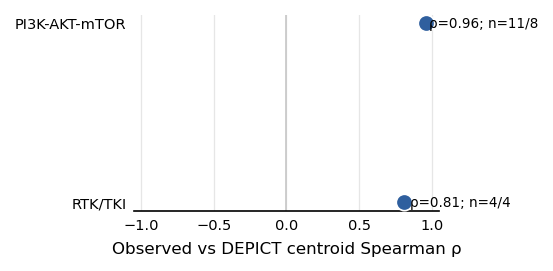

Displayed and saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DrugScreening/figures/figure2/fig2d_right_class_centroid_spearman_dotplot_polished.pdf


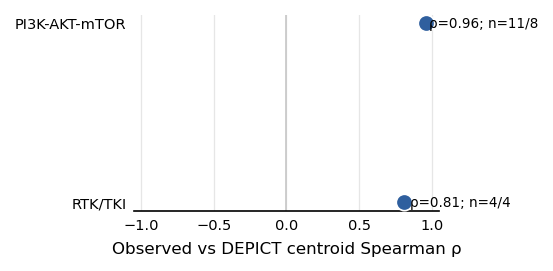

In [16]:

# %%
# Compact side plot: class-level observed-vs-DEPICT Spearman correlations.
required_col = "spearman_rho_observed_vs_depict_centroid"
if class_corr.empty or required_col not in class_corr.columns:
    print("No class-correlation table available. Check whether both observed and DEPICT classes had matched DGE profiles.")
else:
    plot_corr = class_corr.dropna(subset=[required_col]).copy()
    if plot_corr.empty:
        print("No class had enough paired observed/DEPICT pathway values to calculate Spearman correlation.")
        display(class_corr)
    else:
        plot_corr["broad_moa_class"] = pd.Categorical(plot_corr["broad_moa_class"], categories=MOA_CLASSES_FOR_2D_RIGHT, ordered=True)
        plot_corr = plot_corr.sort_values("broad_moa_class")

        fig, ax = plt.subplots(figsize=(3.7, 1.85))
        y = np.arange(plot_corr.shape[0])
        ax.axvline(0, color="0.78", lw=0.8)
        ax.scatter(plot_corr[required_col], y, s=62, color="#2F5F9E", edgecolor="white", linewidth=0.8, zorder=3)
        for yi, (_, row) in zip(y, plot_corr.iterrows()):
            ax.text(
                min(0.98, row[required_col] + 0.045),
                yi,
                f"ρ={row[required_col]:.2f}; n={int(row['n_observed_drugs'])}/{int(row['n_depict_drugs'])}",
                va="center",
                ha="left",
                fontsize=6.5,
            )
        ax.set_yticks(y)
        ax.set_yticklabels(plot_corr["broad_moa_class"])
        ax.set_xlim(-1.05, 1.05)
        ax.set_xlabel("Observed vs DEPICT centroid Spearman ρ")
        ax.grid(axis="x", color="0.90", lw=0.6)
        ax.tick_params(axis="both", length=0)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.invert_yaxis()

        save_figure(fig, "fig2d_right_class_centroid_spearman_dotplot_polished", show=True)
